In [43]:
import re
import pandas as pd
import numpy as np

from pathlib import Path

from pythainlp.tokenize import word_detokenize
from tqdm import tqdm_notebook

import seaborn as sns


from pythainlp import word_tokenize

import re
import emoji

#viz
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns

# Device Set GPU

In [44]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 3050


In [45]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "./thsarabunnew-webfont.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'TH Sarabun New'

In [46]:
path_folder = Path("data/")

In [47]:
import chardet

rawdata = open(path_folder / "train.txt", 'rb').read()
result = chardet.detect(rawdata)

print(result)

{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [48]:
texts = []
labels = []

with open(path_folder / "train.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

with open(path_folder / "train_label.txt", encoding="utf-8") as f:
    for line in f:
        labels.append(line.strip())

df = pd.DataFrame({ "class": labels, "texts": texts })
del texts
del labels

df.to_csv("_social_media_messages.csv", index=False)

df.shape

(24063, 2)

In [49]:
df.describe()

,class,texts
count,24063,24063
unique,4,24014
top,neu,#ERROR!
freq,13105,31


In [50]:
df.head()

,class,texts
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ
1,neu,คะ
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค
3,neu,😅😅😅
4,neu,สวัสดีวันพุธ แนน อะไรนะ


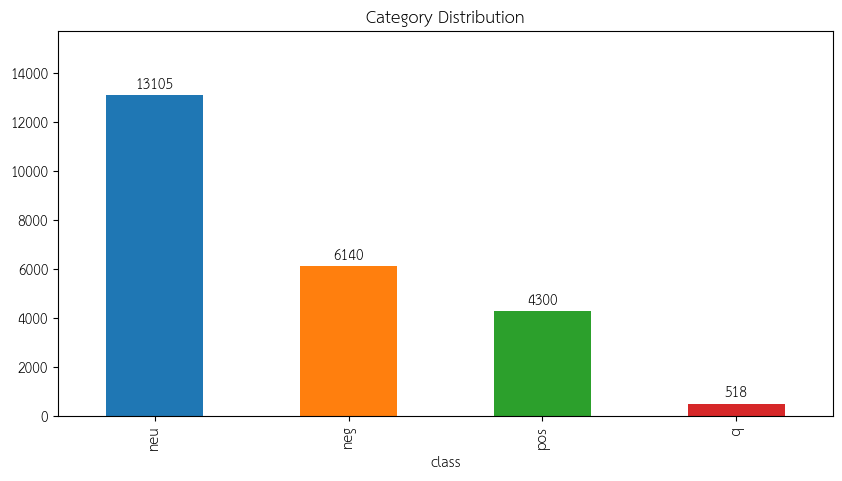

In [51]:
row_count_by_category = df['class'].value_counts()

ax = row_count_by_category.plot(
    kind="bar",
    title="Category Distribution",
    figsize=(10,5),
    color=plt.cm.tab10.colors 
)

ax.set_ylim(0, row_count_by_category.max()*1.2)

for i, label in enumerate(row_count_by_category):
    ax.annotate(
        str(label),
        (i, label + row_count_by_category.max()*0.02),
        ha='center'
    )

plt.show()

In [52]:
df["length"] = df["texts"].apply(word_detokenize).apply(len)
df.head()

,class,texts,length
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ,49
1,neu,คะ,2
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,27
3,neu,😅😅😅,5
4,neu,สวัสดีวันพุธ แนน อะไรนะ,23


In [53]:
df["length"].describe()

count    24063.000000
mean       103.097162
std        179.406963
min          1.000000
25%         20.000000
50%         42.000000
75%        108.000000
max       2946.000000
Name: length, dtype: float64

In [54]:
df[df["length"] >= 740]

,class,texts,length
47,neg,ขออนุญาติ ติบริการของพนักงานทางร้านด้วยค่ะ #mk...,864
52,neu,DJ.ชมพู แจกฟรี! บัตร Chang music แจกอีกครั้งนะ...,818
124,neu,(‘GET 102.5’ ร่วมสร้างปรากฏการณ์เรืองแสงสุดยิ่...,918
141,neu,รพ.กรุงเทพพัทยา จัด Workshop : ไขความลับสุขภาพ...,1075
183,neu,จันทร์ Shock โลก The Return คืนนี้ ดีเจโอ๊ต ปร...,1349
...,...,...,...
23864,neu,"รอบ 8 คน ระทึก ""พุฒ อุบล"" ท้าชน ""จิ๋ว เชียงราย...",823
23983,neu,#เมนูเพื่อสุขภาพจากนักโภชนาการ ฟรุ๊ตสลัดเชื่อม...,955
23991,neu,ใช่ครับผม แต่จะมีบางสาขาเท่านั้นนะคร้าบตอนนี้ต...,826
24020,neu,เกร็ดความรู้ วิธีรักษาสิวแบบธรรมชาติด้วยใบสะเด...,1932


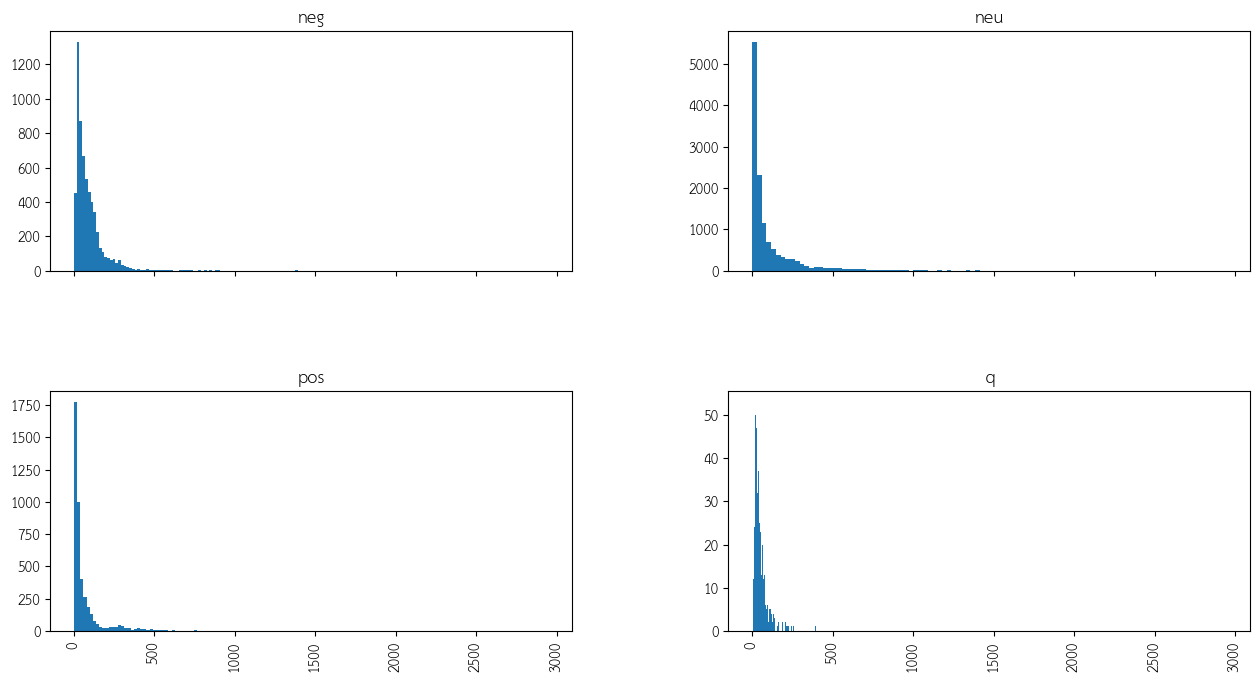

In [55]:
df.hist(column="length", by="class" , bins=100, figsize=(15, 8), sharex=True)
plt.show()

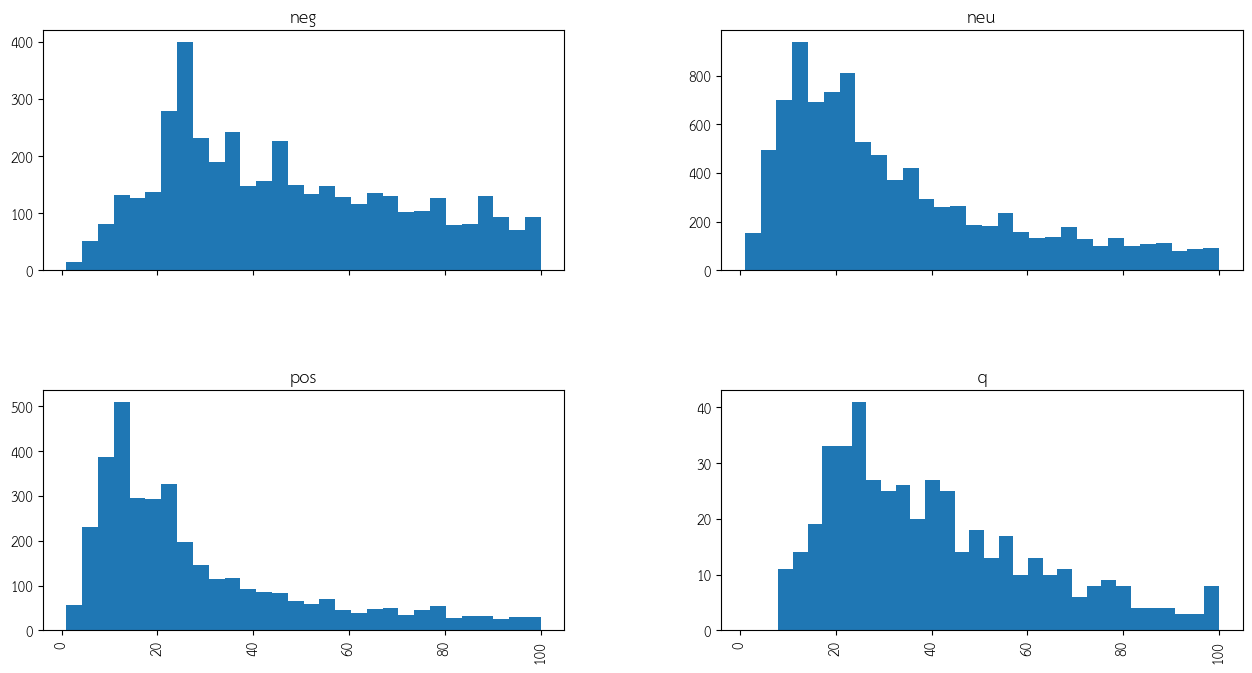

In [56]:
df[df["length"] <= 100].hist(column="length", by="class", bins=30, figsize=(15,8), sharex=True)
plt.show()

#   Preprocess

In [57]:
def replace_url(text):
    URL_PATTERN = r"""(?i)\b((?:https?:(?:/{1,3}|[a-z0-9%])|[a-z0-9.\-]+[.](?:com|net|org|edu|gov|mil|aero|asia|biz|cat|coop|info|int|jobs|mobi|museum|name|post|pro|tel|travel|xxx|ac|ad|ae|af|ag|ai|al|am|an|ao|aq|ar|as|at|au|aw|ax|az|ba|bb|bd|be|bf|bg|bh|bi|bj|bm|bn|bo|br|bs|bt|bv|bw|by|bz|ca|cc|cd|cf|cg|ch|ci|ck|cl|cm|cn|co|cr|cs|cu|cv|cx|cy|cz|dd|de|dj|dk|dm|do|dz|ec|ee|eg|eh|er|es|et|eu|fi|fj|fk|fm|fo|fr|ga|gb|gd|ge|gf|gg|gh|gi|gl|gm|gn|gp|gq|gr|gs|gt|gu|gw|gy|hk|hm|hn|hr|ht|hu|id|ie|il|im|in|io|iq|ir|is|it|je|jm|jo|jp|ke|kg|kh|ki|km|kn|kp|kr|kw|ky|kz|la|lb|lc|li|lk|lr|ls|lt|lu|lv|ly|ma|mc|md|me|mg|mh|mk|ml|mm|mn|mo|mp|mq|mr|ms|mt|mu|mv|mw|mx|my|mz|na|nc|ne|nf|ng|ni|nl|no|np|nr|nu|nz|om|pa|pe|pf|pg|ph|pk|pl|pm|pn|pr|ps|pt|pw|py|qa|re|ro|rs|ru|rw|sa|sb|sc|sd|se|sg|sh|si|sj|Ja|sk|sl|sm|sn|so|sr|ss|st|su|sv|sx|sy|sz|tc|td|tf|tg|th|tj|tk|tl|tm|tn|to|tp|tr|tt|tv|tw|tz|ua|ug|uk|us|uy|uz|va|vc|ve|vg|vi|vn|vu|wf|ws|ye|yt|yu|za|zm|zw)/)(?:[^\s()<>{}\[\]]+|\([^\s()]*?\([^\s()]+\)[^\s()]*?\)|\([^\s]+?\))+(?:\([^\s()]*?\([^\s()]+\)[^\s()]*?\)|\([^\s]+?\)|[^\s`!()\[\]{};:'".,<>?«»“”‘’])|(?:(?<!@)[a-z0-9]+(?:[.\-][a-z0-9]+)*[.](?:com|net|org|edu|gov|mil|aero|asia|biz|cat|coop|info|int|jobs|mobi|museum|name|post|pro|tel|travel|xxx|ac|ad|ae|af|ag|ai|al|am|an|ao|aq|ar|as|at|au|aw|ax|az|ba|bb|bd|be|bf|bg|bh|bi|bj|bm|bn|bo|br|bs|bt|bv|bw|by|bz|ca|cc|cd|cf|cg|ch|ci|ck|cl|cm|cn|co|cr|cs|cu|cv|cx|cy|cz|dd|de|dj|dk|dm|do|dz|ec|ee|eg|eh|er|es|et|eu|fi|fj|fk|fm|fo|fr|ga|gb|gd|ge|gf|gg|gh|gi|gl|gm|gn|gp|gq|gr|gs|gt|gu|gw|gy|hk|hm|hn|hr|ht|hu|id|ie|il|im|in|io|iq|ir|is|it|je|jm|jo|jp|ke|kg|kh|ki|km|kn|kp|kr|kw|ky|kz|la|lb|lc|li|lk|lr|ls|lt|lu|lv|ly|ma|mc|md|me|mg|mh|mk|ml|mm|mn|mo|mp|mq|mr|ms|mt|mu|mv|mw|mx|my|mz|na|nc|ne|nf|ng|ni|nl|no|np|nr|nu|nz|om|pa|pe|pf|pg|ph|pk|pl|pm|pn|pr|ps|pt|pw|py|qa|re|ro|rs|ru|rw|sa|sb|sc|sd|se|sg|sh|si|sj|Ja|sk|sl|sm|sn|so|sr|ss|st|su|sv|sx|sy|sz|tc|td|tf|tg|th|tj|tk|tl|tm|tn|to|tp|tr|tt|tv|tw|tz|ua|ug|uk|us|uy|uz|va|vc|ve|vg|vi|vn|vu|wf|ws|ye|yt|yu|za|zm|zw)\b/?(?!@)))"""
    return re.sub(URL_PATTERN, 'xxurl', text)

def replace_rep(text):
    def _replace_rep(m):
        c,cc = m.groups()
        return f'{c}xxrep'
    re_rep = re.compile(r'(\S)(\1{2,})')
    return re_rep.sub(_replace_rep, text)

def ungroup_emoji(toks):
    res = []
    for tok in toks:
        if emoji.emoji_count(tok) == len(tok):
            for char in tok:
                res.append(char)
        else:
            res.append(tok)
    return res

def process_text(text):
    #pre rules
    res = text.lower().strip()
    res = replace_url(res)
    res = replace_rep(res)
    
    #tokenize
    res = [word for word in word_tokenize(res) if word and not re.search(pattern=r"\s+", string=word)]
    
    #post rules
    res = ungroup_emoji(res)
    
    return res

In [58]:
import re
import string
import emoji
from pythainlp.util import normalize, emoji_to_thai
from pythainlp.corpus import thai_stopwords

# ==========================================
# 1. ฟังก์ชันระดับ String (Pre-processing)
# ==========================================
def replace_url(text):
    # ใช้ Regex ที่คุณให้มา (ย่อให้สั้นลงเพื่อความอ่านง่ายในตัวอย่างนี้ แต่ใช้ของเดิมของคุณได้เลย)
    URL_PATTERN = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    return re.sub(URL_PATTERN, 'xxurl', text)

def replace_rep(text):
    def _replace_rep(m):
        c, cc = m.groups()
        return f'{c}xxrep'
    re_rep = re.compile(r'(\S)(\1{2,})')
    return re_rep.sub(_replace_rep, text)

def remove_numbers(text):
    return re.sub(r'\d+', ' ', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_not_thai(text):
    # เก็บเฉพาะภาษาไทย, ช่องว่าง, และคำพิเศษอย่าง xxurl, xxrep
    # (หากต้องการเก็บภาษาอังกฤษไว้ด้วย ให้เติม a-zA-Z ใน regex)
    return re.sub(r'[^\u0E00-\u0E7Fa-zA-Z\s]', ' ', text)

def remove_extra_white_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()


# ==========================================
# 2. ฟังก์ชันระดับ Tokens (Post-processing)
# ==========================================
def ungroup_emoji(toks):
    res = []
    for tok in toks:
        if emoji.emoji_count(tok) == len(tok) and len(tok) > 0:
            for char in tok:
                res.append(char)
        else:
            res.append(tok)
    return res

def remove_stopwords_from_tokens(tokens):
    stopwords = frozenset(thai_stopwords())
    # ไม่ลบคำพิเศษที่เราสร้างขึ้นมา
    return [word for word in tokens if word not in stopwords or word in ['xxurl', 'xxrep']]


# ==========================================
# 3. ประกอบร่าง Pipeline (Main Function)
# ==========================================
def process_thai_text_pipeline(text, convert_emoji=False):
    """
    ฟังก์ชันหลักสำหรับ Clean ข้อความภาษาไทย
    - convert_emoji: ถ้า True จะแปลง Emoji เป็นคำภาษาไทย ถ้า False จะแยก Emoji ออกเป็นตัวๆ
    - remove_stop: ถ้า True จะลบคำฟุ่มเฟือย (Stopwords)
    """
    # --- 1. String-level Rules ---
    res = text.lower().strip()
    res = replace_url(res)
    res = replace_rep(res)
    
    # จัดการ Emoji (เลือกแปลงเป็นคำไทย หรือเก็บไว้แยกตัวทีหลัง)
    if convert_emoji:
        res = emoji_to_thai(res)
        
    res = normalize(res) # จัดการสระ/วรรณยุกต์ภาษาไทย
    
    # ลบสิ่งที่ไม่ต้องการออก (เรียงลำดับให้ดีเพื่อไม่ให้กระทบคำพิเศษ)
    res = remove_numbers(res)
    res = remove_punctuation(res)
    res = remove_extra_white_spaces(res)
    

   
    
  
        
    return res

In [59]:
df = pd.read_csv('_social_media_messages.csv')

df['texts'] = df.texts.map(lambda x: process_thai_text_pipeline(x, convert_emoji=True))


In [60]:
df.head()

,class,texts
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ
1,neu,คะ
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค
3,neu,ยิ้มเหงื่อตกxxrep
4,neu,สวัสดีวันพุธ แนน อะไรนะ


In [61]:
df.head()

,class,texts
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ
1,neu,คะ
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค
3,neu,ยิ้มเหงื่อตกxxrep
4,neu,สวัสดีวันพุธ แนน อะไรนะ


# Neutral, Positive, Negative

In [62]:
neu_df = df[df['class'] == "neu"].sample(5000)
neu_df.head()

,class,texts
19565,neu,กิเลนผยอง ผ่านเข้ารอบตามคาด หลังถล่ม รถม้ามรกต...
7699,neu,อเครๆ ไว้ไปกันนะคะ
8506,neu,ปักหลักบาบีก้อนหมุดปักxxrep
15671,neu,หนูทักไปละนะ ce จุ้บๆ
13822,neu,จะบร้าxxrepหรายัยอ้วนน


In [63]:
pos_df = df[df['class'] == "pos"]
pos_df.head()

,class,texts
10,pos,สนใจ ฟอจูนเนอร์ สีขาวครับ
16,pos,ไปดิรอไร
19,pos,อยากกินบาบีก้อนหรอ xxrep
22,pos,ต้องไปลองกันนะ
25,pos,ขอให้ sheene มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เ...


In [64]:
neg_df = df[df['class'] == "neg"]
neg_df.head()

,class,texts
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค
6,neg,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ต...
8,neg,เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ
11,neg,ลิปมันของแบร์น mistine ราคากลาง ๆ ไม่แพงมาก รา...
12,neg,ทำไมมันไม่มีโปรให้เร๊าxxrep


In [65]:
sentiment_df = pd.concat([neg_df, pos_df, neu_df])
sentiment_df = sentiment_df.reset_index(drop=True)
sentiment_df.groupby("class").texts.describe()


,count,unique,top,freq
class,,,,
neg,6140,6126,error,12
neu,5000,4967,error,7
pos,4300,4234,อยากกินxxrep,8


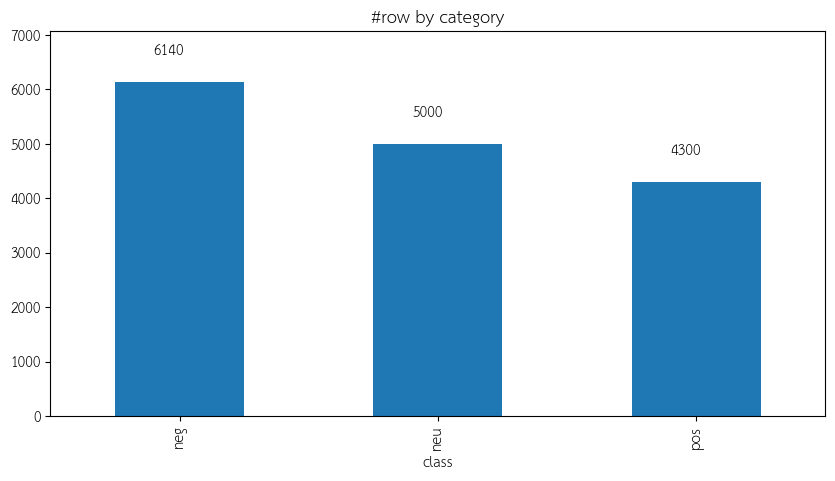

In [66]:
row_count_by_category = sentiment_df['class'].value_counts()
ax = row_count_by_category.plot(kind="bar", title="#row by category", figsize=(10, 5))
ax.set_ylim(0, row_count_by_category.max() + row_count_by_category.std())
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i-0.1, label + 500))

# Classification
- ML Classification


In [67]:
class_names = np.unique(sentiment_df['class']).tolist()
print(class_names)

['neg', 'neu', 'pos']


In [68]:

from pythainlp import word_tokenize
def thai_tokenizer(text):
    return word_tokenize(text)

# Tfidf Vectorizer test

In [69]:
#text faetures

from sklearn.feature_extraction.text import TfidfVectorizer



vectorizer = TfidfVectorizer(tokenizer=thai_tokenizer,token_pattern=None,binary=True, smooth_idf=False)
X = vectorizer.fit_transform(sentiment_df['texts'][0:5])
X = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
X 

,,lashesactivity,m,mistine,xxrep,กลาง,กว่า,กัน,กาก,กิน,...,โค,โทร,โปร,ใบ,ให้,ได้,ไป,ไม่,ไว้,ๆ
0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.351829,...,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000
1,0.064817,0.000000,0.11195,0.000000,0.000000,0.000000,0.11195,0.11195,0.11195,0.000000,...,0.11195,0.11195,0.082213,0.11195,0.000000,0.000000,0.11195,0.052475,0.11195,0.082213
2,0.197048,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,...,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.159528,0.00000,0.000000
3,0.156356,0.270052,0.00000,0.270052,0.000000,0.270052,0.00000,0.00000,0.00000,0.000000,...,0.00000,0.00000,0.000000,0.00000,0.000000,0.270052,0.00000,0.126584,0.00000,0.198318
4,0.000000,0.000000,0.00000,0.000000,0.398463,0.000000,0.00000,0.00000,0.00000,0.000000,...,0.00000,0.00000,0.292619,0.00000,0.398463,0.000000,0.00000,0.186775,0.00000,0.000000


# TF-IDF

In [70]:
#text faetures

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(tokenizer=thai_tokenizer,token_pattern=None,binary=True, smooth_idf=False)
X = vectorizer.fit_transform(sentiment_df['texts'])
X = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
X = np.array(X)

In [71]:
 
Y = sentiment_df['class'].to_numpy()
num_class = sentiment_df['class'].value_counts()
print(num_class)

class
neg    6140
neu    5000
pos    4300
Name: count, dtype: int64


# Data Split

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(12352, 18876) (3088, 18876) (12352,) (3088,)


In [73]:
print(X_train)

[[0.04760274 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.06763112 0.         0.         ... 0.         0.         0.        ]
 [0.06988199 0.         0.         ... 0.         0.         0.        ]
 [0.11252104 0.         0.         ... 0.         0.         0.        ]]


# LogisticRegression

In [74]:
from sklearn.linear_model import LogisticRegression

lgs_clf = LogisticRegression(max_iter=200, random_state=42)

lgs_clf.fit(X_train, y_train)
lgs_clf.score(X_test, y_test)



0.6991580310880829

In [ ]:
from sklearn.metrics import classification_report

test_predictions = lgs_clf.predict(X_test)
report = classification_report(y_test, test_predictions,digits=4)
print("Logistic Regression Classification Report:")
print(report)

              precision    recall  f1-score   support

         neg     0.7619    0.8316    0.7952      1247
         neu     0.6147    0.6495    0.6316       953
         pos     0.6986    0.5664    0.6256       888

    accuracy                         0.6992      3088
   macro avg     0.6917    0.6825    0.6842      3088
weighted avg     0.6983    0.6992    0.6960      3088



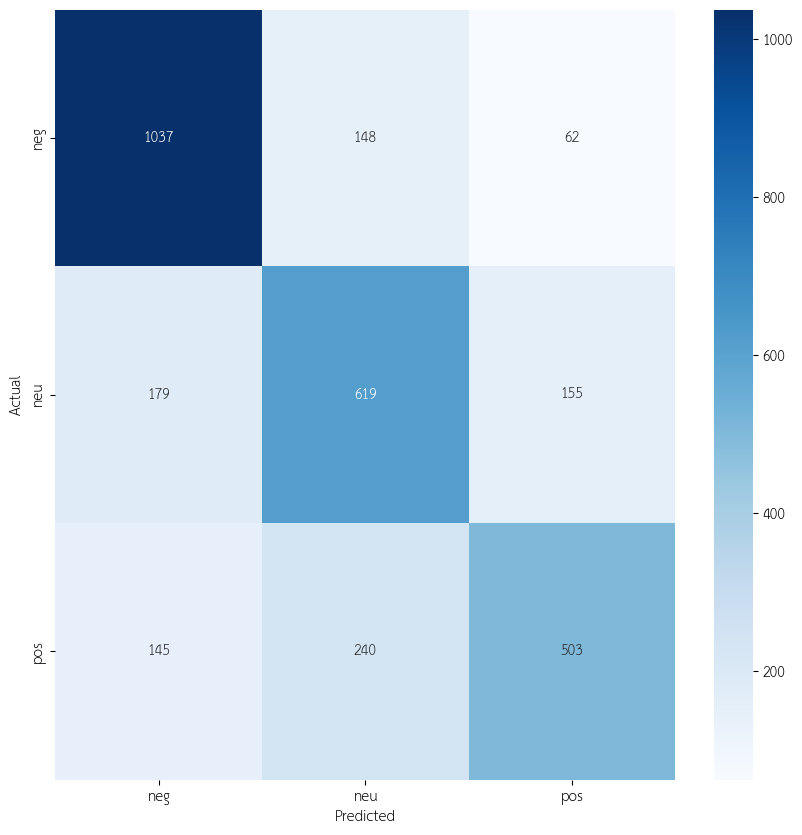

In [76]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, lgs_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat,annot=True, fmt="d", cbar=True,cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Model predict

In [77]:
def predict_sentiment(text):

    text_vec = vectorizer.transform([text])
    pred = lgs_clf.predict(text_vec)[0]

    return pred

# ทดสอบกับข้อความตัวอย่าง
text_example = "คงจะมีแต่แชมพูเท่านั้นแหละ ที่เป็นห่วงผม"
if predict_sentiment(text_example) == "pos":
    print("Predicted sentiment: Positive")
elif predict_sentiment(text_example) == "neg":
    print("Predicted sentiment: Negative")
else:
    print("Predicted sentiment: Neutral")


Predicted sentiment: Negative


# Save model

In [78]:
import joblib
import joblib

joblib.dump(lgs_clf, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

# Support Vector Machine

In [79]:
from sklearn.svm import LinearSVC

svc_clf = LinearSVC()

svc_clf.fit(X_train, y_train)
svc_clf.score(X_test, y_test)



0.6787564766839378

# evaluation ประเมินประสิทธิภาพ

In [ ]:
from sklearn.metrics import classification_report

test_predictions = svc_clf.predict(X_test)
report = classification_report(y_test, test_predictions,digits=4)
print("Linear SVC Classification Report:")
print(report)

              precision    recall  f1-score   support

         neg     0.7567    0.8107    0.7828      1247
         neu     0.6015    0.6002    0.6008       953
         pos     0.6404    0.5777    0.6075       888

    accuracy                         0.6788      3088
   macro avg     0.6662    0.6629    0.6637      3088
weighted avg     0.6754    0.6788    0.6762      3088



# Confusion matrix

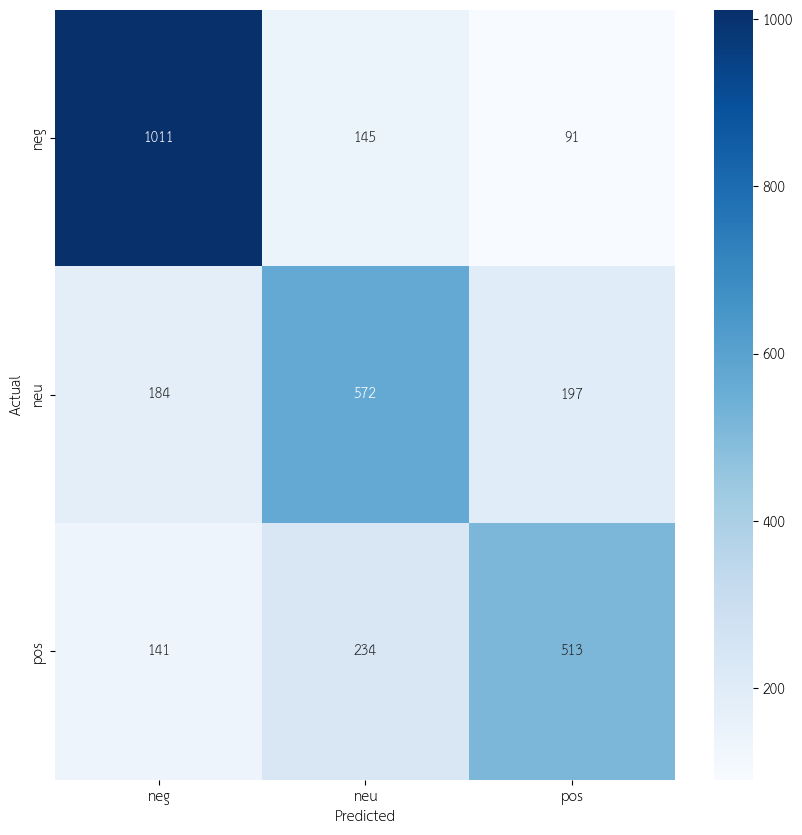

In [81]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, svc_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat,annot=True, fmt="d", cbar=True,cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

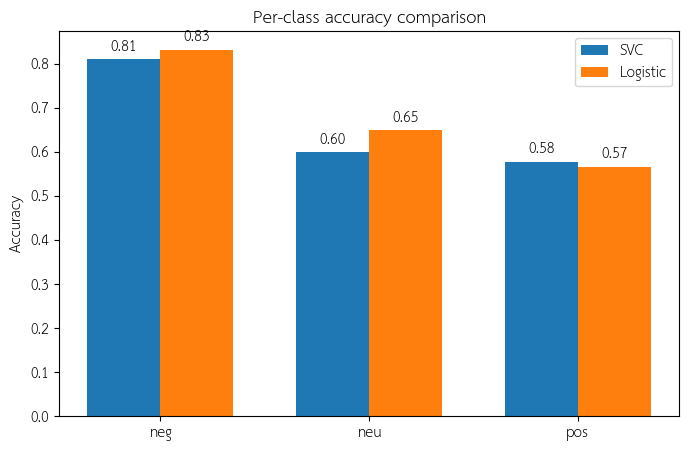

In [82]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

svc_preds = svc_clf.predict(X_test)
lgs_preds = lgs_clf.predict(X_test)

classes = class_names
svc_acc = []
lgs_acc = []
for cls in classes:
    idxs = y_test == cls
    svc_acc.append(accuracy_score(y_test[idxs], svc_preds[idxs]))
    lgs_acc.append(accuracy_score(y_test[idxs], lgs_preds[idxs]))




x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, svc_acc, width, label='SVC')
rects2 = ax.bar(x + width/2, lgs_acc, width, label='Logistic')

ax.set_ylabel('Accuracy')
ax.set_title('Per-class accuracy comparison')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0,3), textcoords='offset points',
                ha='center', va='bottom')
plt.show()


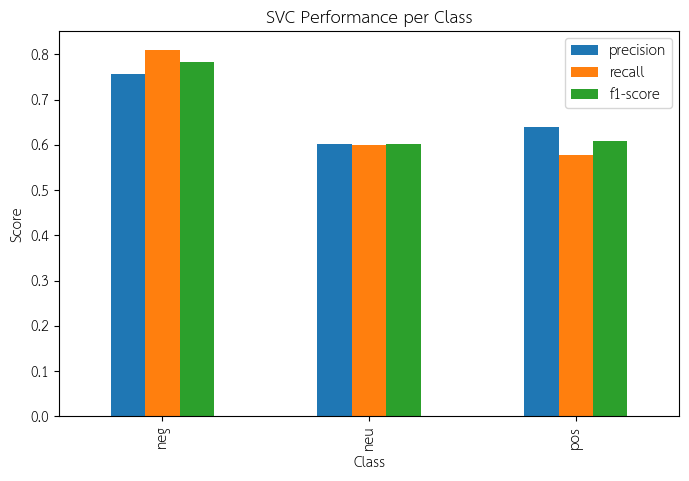

In [83]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Predict
test_predictions = svc_clf.predict(X_test)

# เอา report เป็น dictionary
report_dict = classification_report(
    y_test,
    test_predictions,
    output_dict=True
)

# แปลงเป็น DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# เลือกเฉพาะ class
df_plot = df_report.loc[['neg','neu','pos'],['precision','recall','f1-score']]

# Plot
df_plot.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Score")
plt.xlabel("Class")
plt.title("SVC Performance per Class")

plt.show()

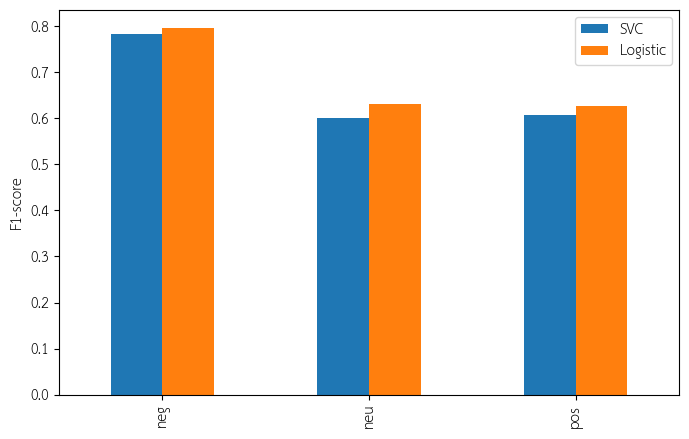

In [84]:
svc_pred = svc_clf.predict(X_test)
lgs_pred = lgs_clf.predict(X_test)

svc_rep = classification_report(y_test, svc_pred, output_dict=True)
lgs_rep = classification_report(y_test, lgs_pred, output_dict=True)

svc_df = pd.DataFrame(svc_rep).transpose()
lgs_df = pd.DataFrame(lgs_rep).transpose()

svc_plot = svc_df.loc[['neg','neu','pos'],'f1-score']
lgs_plot = lgs_df.loc[['neg','neu','pos'],'f1-score']

compare = pd.DataFrame({
    "SVC":svc_plot,
    "Logistic":lgs_plot
})

compare.plot(kind='bar',figsize=(8,5))

plt.ylabel("F1-score")

plt.show()